German Traffic Sign Recognition Benchmark

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [2]:
import kagglehub

path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [3]:
transform_train = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

transform_test = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

train_dir = os.path.join(path, 'Train')

full_data  = datasets.ImageFolder(root=train_dir, transform=transform_train)
class_names = full_data.classes
print("Классов:", len(class_names))
print("Всего изображений:", len(full_data))

Классов: 43
Всего изображений: 39209


In [4]:
train_size = int(0.8 * len(full_data))
val_size   = len(full_data) - train_size
train_data, val_data = random_split(full_data, [train_size, val_size])

val_data.dataset.transform = transform_test

train = DataLoader(train_data, batch_size=64, shuffle=True)
val   = DataLoader(val_data,   batch_size=64)

print(f"Train: {train_size} | Val: {val_size}")

Train: 31367 | Val: 7842


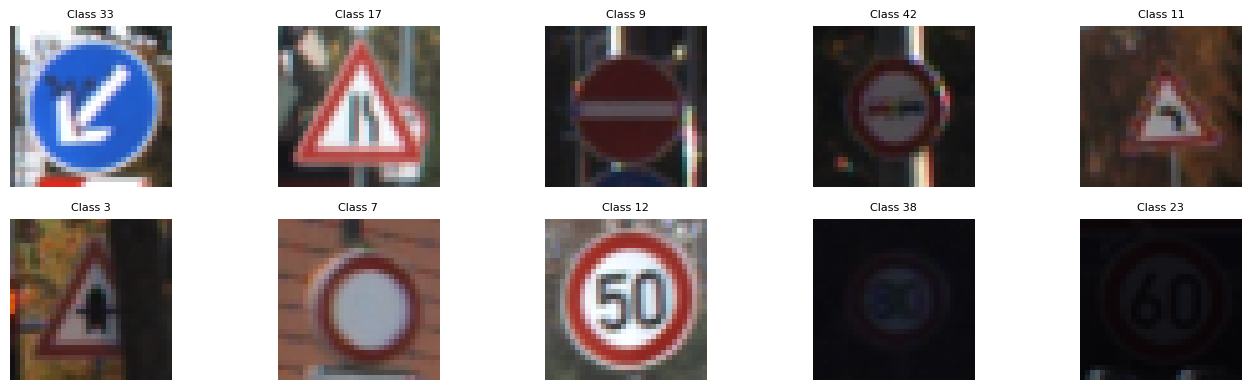

In [5]:
images, labels = next(iter(train))

plt.figure(figsize=(14, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = images[i].permute(1, 2, 0) * 0.5 + 0.5
    plt.imshow(img.clamp(0, 1))
    plt.title(f'Class {labels[i].item()}', fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.savefig('sample_signs.png')
plt.show()

In [6]:
class TrafficSignClassifier(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()

        self.features = nn.Sequential(
            # Блок 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            # Блок 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),

            # Блок 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [7]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

In [8]:
model = TrafficSignClassifier(num_classes=43).to(device)

In [9]:
loss_fn   = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [11]:
for epoch in range(30):
    model.train()
    total_loss = 0
    for x_batch, y_batch in train:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model(x_batch)
        loss   = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    # Валидация каждые 5 эпох
    if (epoch + 1) % 5 == 0:
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x_batch, y_batch in val:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                prediction = model(x_batch).argmax(dim=1)
                total   += y_batch.size(0)
                correct += (prediction == y_batch).sum().item()
        acc = correct * 100 / total
        print(f'Эпоха {epoch + 1:02d} -- Потери: {round(total_loss, 2)} | Val accuracy: {round(acc, 2)}%')
    else:
        print(f'Эпоха {epoch + 1:02d} -- Потери: {round(total_loss, 2)}')

Эпоха 01 -- Потери: 947.98
Эпоха 02 -- Потери: 265.03
Эпоха 03 -- Потери: 95.31
Эпоха 04 -- Потери: 64.14
Эпоха 05 -- Потери: 47.81 | Val accuracy: 99.23%
Эпоха 06 -- Потери: 44.16
Эпоха 07 -- Потери: 35.99
Эпоха 08 -- Потери: 30.17
Эпоха 09 -- Потери: 29.03
Эпоха 10 -- Потери: 23.36 | Val accuracy: 99.53%
Эпоха 11 -- Потери: 14.65
Эпоха 12 -- Потери: 11.28
Эпоха 13 -- Потери: 11.7
Эпоха 14 -- Потери: 11.45
Эпоха 15 -- Потери: 8.74 | Val accuracy: 99.82%
Эпоха 16 -- Потери: 9.01
Эпоха 17 -- Потери: 8.19
Эпоха 18 -- Потери: 9.73
Эпоха 19 -- Потери: 8.08
Эпоха 20 -- Потери: 7.65 | Val accuracy: 99.8%
Эпоха 21 -- Потери: 6.58
Эпоха 22 -- Потери: 5.81
Эпоха 23 -- Потери: 3.65
Эпоха 24 -- Потери: 3.79
Эпоха 25 -- Потери: 4.01 | Val accuracy: 99.77%
Эпоха 26 -- Потери: 3.66
Эпоха 27 -- Потери: 4.01
Эпоха 28 -- Потери: 3.21
Эпоха 29 -- Потери: 3.36
Эпоха 30 -- Потери: 2.79 | Val accuracy: 99.81%


In [12]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for x_batch, y_batch in val:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        prediction = model(x_batch).argmax(dim=1)
        total   += y_batch.size(0)
        correct += (prediction == y_batch).sum().item()

accuracy = correct * 100 / total
print(f'Точность на валидации: {round(accuracy, 2)}%')

Точность на валидации: 99.81%


In [17]:
from google.colab import files

torch.save(class_names, 'labels_PDD_TrafficSignClassifier.pth')
torch.save(model.state_dict(), 'model_PDD_TrafficSignClassifier.pth')

files.download('labels_PDD_TrafficSignClassifier.pth')
files.download('model_PDD_TrafficSignClassifier.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>